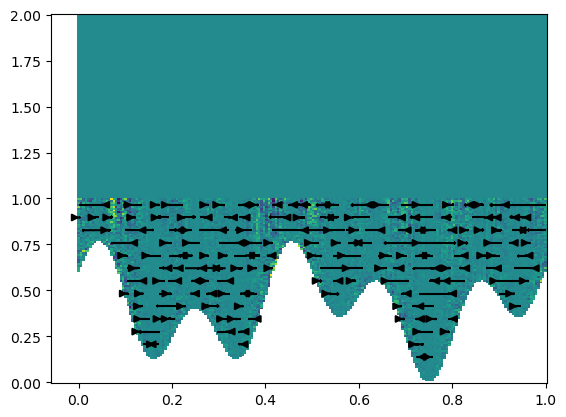

In [5]:
from jax import grad, jit, vmap, jacrev
import jax.numpy as np
import numpy as nnp
import matplotlib.pyplot as plt
from jax.lax import cond


beta = 1
alpha = 2
rho = 1.0
eps = 0.2
f = lambda x: (np.sin(2*np.pi*5*x) + np.cos(2*np.pi*2*x)+2)*eps

plus = lambda vec1, vec2: (vec1[0]+vec2[0], vec1[1]+vec2[1])
mult = lambda vec, c: (vec[0]*c, vec[1]*c)
phi = lambda f, y: (y-f)/(beta - f)
u_phi = lambda phi, df: (rho*(3*phi - 2)*phi, -2*rho*df*phi*(1 - phi)**2)
u_lower = lambda f: lambda x, y: u_phi(phi(f(x), y), grad(f)(x))
u_whole = lambda f, beta, alpha, U, eps: lambda x, y:  cond(y<beta, 
                                                           lambda x, y: mult(u_lower(f)(x, y), U*eps), 
                                                           lambda x, y: (((y - beta) + eps*(alpha - y))*U/(alpha - beta), 0.),
                                                           x,y)


x = np.linspace(0, 1, 200)
y = np.linspace(0, 2, 200)
#y = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x, y)
mask = Y > f(X)

#(U, V) = jit(vmap(vmap(u(f), (0, 0)), (0, 0)))(X, Y)
u = u_whole(f, beta, alpha, 1, eps)
dudy = jacrev(u, argnums=1)
dudx = jacrev(u, argnums=0)
ddudxx = jacrev(dudx, argnums=0)
ddudyy = jacrev(dudy, argnums=1)
laplaceu = lambda x, y: plus(ddudxx(x, y),ddudyy(x, y))
divu = lambda x, y: (dudx(x, y)[0] + dudy(x, y)[1], 0)

(U, V) = vmap(vmap(divu, (0, 0)), (0, 0))(X, Y)
U = np.where(mask, U, np.nan)
V = np.where(mask, V, np.nan)
plt.pcolormesh(X, Y, U)
ar = lambda x: nnp.array(x)
plt.streamplot(ar(X), ar(Y), ar(U), ar(V), color='k')



In [4]:

x = lambda a,b: cond(a>b, lambda a, b: a*a, lambda a,b: b*b, a, b)
print(x(1,2))


4
